In [19]:
import os
if 'experiments' in os.getcwd ():
    os.chdir (os.getcwd () + "/..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
####### DATA PATHS #######
TRAIN_PATH = "./data/in/cattle_data_train.csv"
TEST_PATH = "./data/in/cattle_data_test.csv"
OUT_PATH = "./data/out/nnet.csv"


# Some observations
# Breed: Holstein, Jersey, Guernsey, Brown Swiss
# Climate_Zone: Tropical, Arid, Mediterranean, Subtropical, Continental, Temperate
# Management_System: Intensive, Mixed, Semi_Intensive, Pastoral, Extensive
# Age_Months: [22.5, 142.5]
# Weight_kg: [250, 750]
# Parity: [1, 6]
# Lactation_Stage: Mid, Late, Early
# Days_in_Milk: [0, 365]
# Feed_Type: Concentrates, Crop_Residues, Hay, Mixed_Feed, Silage, Dry_Fodder, Pasture_Grass, Green_Fodder
# Feed_Quantity_kg: [1, 25] <- Check if it correlates with weight.. it should
# Feeding_Frequency: [1, 5]
# Water_Intake_L: [30, 130] <- Check if it correlates with weight.. it should
# Walking_Distance_km: [0.5, 10.5] <- 8k records at 0.5
# Grazing_Duration_hrs: [1, 14] <- 10k records at 1
# Rumination_Time_hrs: [-8, 25] <- Why negative??
# Resting_Hours: [5, 18] <- 12k records at 5.. Check that all records satisfy the total time above is <= 24
# Ambient_Temperature_C: [-12, 47] <- High temperature seems too high, that would imply ambient temperature at around 110+ degrees F
# Humidity_percent: [10, 100] <- 2k at 10, 5k at 100.. seems a little high?
# Housing_Score: [0.27, 1.02] <- This is qualitative, probably should remove if it doesnt correlate well
# Previous_Week_Avg_Yield: [0, 30] <- 8k at 0.. check if it correlates
# Feed_Quantity_lb: <- Check if this matches with Feed_Quantity_kg.

# Milk_Yield_L: Remove records with negative values,

In [21]:
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
TARGET_FEATURE = "Milk_Yield_L"

DROP_FEATURES = [
    "Cattle_ID",
    "Farm_ID",
    "Feed_Quantity_lb",
    "Breed",
    "Climate_Zone",
    "Management_System",
    "Feed_Type",
    "Feeding_Frequency",
    "Walking_Distance_km",
    "Grazing_Duration_hrs",
    "Rumination_Time_hrs",
    "Resting_Hours",
    "Body_Condition_Score",
    "Humidity_percent",
    "BVD_Vaccine",
    "FMD_Vaccine",
    "Brucellosis_Vaccine",
    "HS_Vaccine",
    "BQ_Vaccine",
    "Housing_Score",
]
CATEGORICAL_FEATURES = [
    "Lactation_Stage",
    "Date",
]
STANDARD_SCALED_FEATURES = [
    "Age_Months",
    "Weight_kg",
    "Parity",
    "Days_in_Milk",
    "Feed_Quantity_kg",
    "Water_Intake_L",
    "Ambient_Temperature_C",
    "Previous_Week_Avg_Yield",
    "Milking_Interval_hrs",
]

def preprocess(dtrain, dtest):
    # Drop features deemed unnecessary
    
    dtrain = dtrain.drop(DROP_FEATURES, axis=1)
    dtest = dtest.drop(DROP_FEATURES, axis=1)

    # Fix typos/inconsistencies in the data
    if "Breed" not in DROP_FEATURES:
        dtrain["Breed"] = dtrain["Breed"].replace({
            "Holstien": "Holstein",
            " Brown Swiss": "Brown Swiss",
            "Brown Swiss ": "Brown Swiss"
        })
        dtest["Breed"] = dtest["Breed"].replace({
            "Holstien": "Holstein",
            " Brown Swiss": "Brown Swiss",
            "Brown Swiss ": "Brown Swiss"
        })
    
    # Convert month to season
    def month_to_season (m):
            if m in [12, 1, 2]:
                return "Winter"
            elif m in [3, 4, 5]:
                return "Spring"
            elif m in [6, 7, 8]:
                return "Summer"
            else:
                return "Fall"
            
    if "Date" not in DROP_FEATURES:
        months = pd.to_datetime (dtest['Date']).dt.month
        dtest = dtest.drop (columns = ['Date'])
        dtest['Date'] = months.apply (month_to_season)

        months = pd.to_datetime (dtrain['Date']).dt.month
        dtrain = dtrain.drop (columns = ['Date'])
        dtrain['Date'] = months.apply (month_to_season)

    # Random sampling imputation
    if "Feed_Quantity_kg" not in DROP_FEATURES:
        median_val = dtrain["Feed_Quantity_kg"].median ()

        dtrain.loc[dtrain["Feed_Quantity_kg"].isna (), "Feed_Quantity_kg"] = median_val
        dtest.loc[dtest["Feed_Quantity_kg"].isna (), "Feed_Quantity_kg"] = median_val

    if "Housing_Score" not in DROP_FEATURES:
        hscore_mean = dtrain["Housing_Score"].mean()
        dtrain["Housing_Score"] = dtrain["Housing_Score"].fillna(hscore_mean)
        dtest["Housing_Score"] = dtest["Housing_Score"].fillna(hscore_mean)

    # One-hot encode
    dtrain = pd.get_dummies (dtrain, columns = CATEGORICAL_FEATURES, drop_first = True)
    dtest = pd.get_dummies (dtest, columns = CATEGORICAL_FEATURES, drop_first = True)
    dtrain, dtest = dtrain.align(dtest, join='left', axis=1, fill_value=0)

    # TODO: Do something about unreasonable data records
    dtrain = dtrain.clip(lower=0)
    dtest = dtest.clip(lower=0)
    # if "Rumination_Time_hrs" not in DROP_FEATURES:
        # dtrain = dtrain[dtrain["Rumination_Time_hrs"] >= 0]
        # dtest = dtest[dtest["Rumination_Time_hrs"] ]
    
    return dtrain, dtest

train_data = pd.read_csv(TRAIN_PATH)
X_train, X_test, y_train, y_test = train_test_split(train_data.drop(TARGET_FEATURE, axis=1), train_data[TARGET_FEATURE], test_size=0.2, random_state = 0)

# TODO Should we scale the predicted milk yield too? and then apply the reverse of the scaler (inverse_transform)?

X_train, X_test = preprocess(X_train, X_test)

nan_cols = X_train.columns[X_train.isna().any()]
print("Columns with NaN values:", nan_cols.tolist())

# Standardize data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# TODO  For now, standardize everything. In future, see if min/max scaling is better for non-gaussian data
X_train[STANDARD_SCALED_FEATURES] = scaler.fit_transform(X_train[STANDARD_SCALED_FEATURES])
X_test[STANDARD_SCALED_FEATURES] = scaler.transform(X_test[STANDARD_SCALED_FEATURES])

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

Columns with NaN values: []
(168000, 18)
(168000,)
(42000, 18)
(42000,)


In [22]:
# feature = "Housing_Score"

# print(X_train[X_train[feature].isna()][feature].head(10))

# plt.figure(figsize=(10,5))
# plt.hist(X_train[feature], bins=20, edgecolor='black')
# plt.hist(X_train[X_train[feature] < 0], bins=10, edgecolor='black')
# plt.xlabel(feature)
# plt.ylabel("Count")
# plt.title("Histogram")
# plt.show()

In [23]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# RMSE at each checkpoint
train_rmse_list = []
test_rmse_list = []

total_iterations = 150
iterations_per_step = 10

model = MLPRegressor(
    hidden_layer_sizes = (128, 32),
    activation = "tanh",
    learning_rate_init = 0.0001,
    learning_rate = "adaptive",
    # alpha = 0.001,
    early_stopping = True,
    validation_fraction = 0.15,
    n_iter_no_change = 20,
    verbose = False,
    warm_start = True,
    max_iter = iterations_per_step,
    random_state = 0)

for i in range(iterations_per_step, total_iterations+1, iterations_per_step):
    model.fit(X_train, y_train)

    # Compute RMSE
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_rmse_list.append(train_rmse)
    test_rmse_list.append(test_rmse)

    print(f"Iteration {i}: Train RMSE={train_rmse:.4f}, Test RMSE={test_rmse:.4f}")
    # print("Train R2:", r2_score(y_train, y_train_pred))
    # print("Test R2:", r2_score(y_test, y_test_pred))

/home/osten/.virtualenvs/IPYNB/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 10: Train RMSE=4.2766, Test RMSE=4.2831


/home/osten/.virtualenvs/IPYNB/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 20: Train RMSE=4.1742, Test RMSE=4.1758


/home/osten/.virtualenvs/IPYNB/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


...

Iteration 100: Train RMSE=4.1088, Test RMSE=4.1141


/home/osten/.virtualenvs/IPYNB/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 110: Train RMSE=4.1079, Test RMSE=4.1136


/home/osten/.virtualenvs/IPYNB/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 120: Train RMSE=4.1070, Test RMSE=4.1132
Iteration 130: Train RMSE=4.1063, Test RMSE=4.1128
Iteration 140: Train RMSE=4.1061, Test RMSE=4.1130
Iteration 150: Train RMSE=4.1060, Test RMSE=4.1130


In [24]:
id = 12
record = X_test.iloc[[id]]
print(model.predict(record), y_test.iloc[[id]])

record[STANDARD_SCALED_FEATURES] = scaler.inverse_transform(record[STANDARD_SCALED_FEATURES])
record

[23.13083576] 125292    36.740186
Name: Milk_Yield_L, dtype: float64


/tmp/ipykernel_13570/52782865.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  record[STANDARD_SCALED_FEATURES] = scaler.inverse_transform(record[STANDARD_SCALED_FEATURES])


,Age_Months,Weight_kg,Parity,Days_in_Milk,Feed_Quantity_kg,Water_Intake_L,Ambient_Temperature_C,Anthrax_Vaccine,IBR_Vaccine,Rabies_Vaccine,Previous_Week_Avg_Yield,Milking_Interval_hrs,Mastitis,Lactation_Stage_Late,Lactation_Stage_Mid,Date_Spring,Date_Summer,Date_Winter
125292,56.0,598.1,2.0,59.0,11.229969,80.008265,12.474496,0,1,1,28.01,8.0,0,False,False,False,False,False


In [25]:
y_pred = model.predict(X_train)
rmse = np.sqrt(mean_squared_error(y_train, y_pred))
print("Train RMSE:", rmse)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse)

Train RMSE: 4.105999147942853
Test RMSE: 4.113032609190233


Feature correlations with target (sorted by absolute value):
Age_Months                -0.308774
Weight_kg                  0.300274
Parity                    -0.235672
Feed_Quantity_kg           0.217947
Date_Summer               -0.178212
Water_Intake_L             0.126097
Mastitis                  -0.121919
Date_Spring                0.107560
Previous_Week_Avg_Yield    0.091120
IBR_Vaccine                0.073377
Anthrax_Vaccine            0.069803
Rabies_Vaccine             0.067876
Lactation_Stage_Late      -0.067578
Days_in_Milk              -0.061559
Date_Winter                0.055952
Ambient_Temperature_C     -0.041317
Lactation_Stage_Mid       -0.015069
Milking_Interval_hrs       0.013065
Name: target, dtype: float64


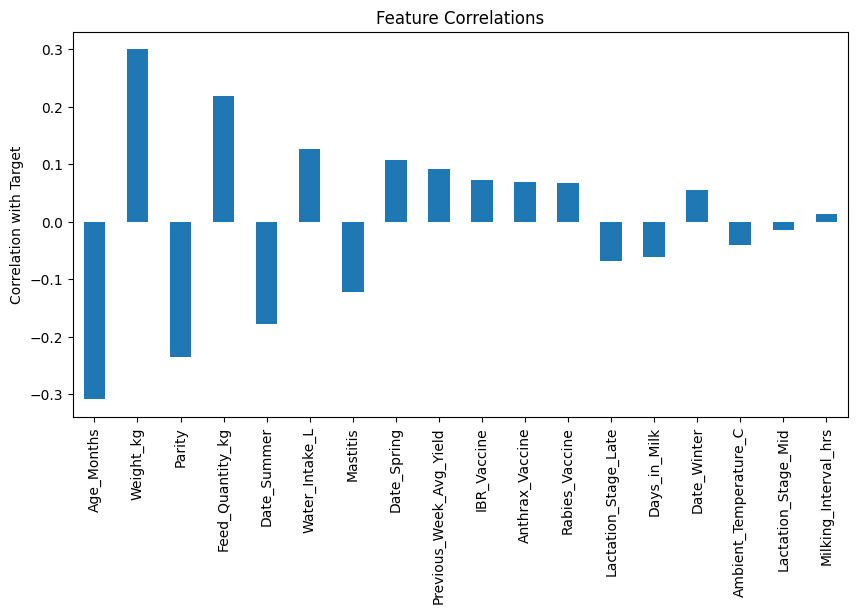

In [26]:
y_series = pd.Series(y_train, name='target')
df = pd.concat([X_train, y_series], axis=1)

correlations = df.corr()['target'].drop('target')
correlations_sorted = correlations.reindex(correlations.abs().sort_values(ascending=False).index)

print("Feature correlations with target (sorted by absolute value):")
print(correlations_sorted)

plt.figure(figsize=(10,5))
correlations_sorted.plot(kind='bar')
plt.ylabel('Correlation with Target')
plt.title('Feature Correlations')
plt.show()

In [27]:
test_data = pd.read_csv (TEST_PATH)
test_data = test_data.drop (DROP_FEATURES, axis = 1)

nan_report = test_data.isna().sum()
print(nan_report[nan_report > 0])


months = pd.to_datetime (test_data['Date']).dt.month
test_data = test_data.drop (columns = ['Date'])

def month_to_season (m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Spring"
    elif m in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"
test_data['Date'] = months.apply (month_to_season)
test_data = pd.get_dummies (test_data, columns = CATEGORICAL_FEATURES, drop_first = True)
median_val = test_data["Feed_Quantity_kg"].median ()
test_data.loc[test_data["Feed_Quantity_kg"].isna(), "Feed_Quantity_kg"] = median_val

test_data[STANDARD_SCALED_FEATURES] = scaler.transform(test_data[STANDARD_SCALED_FEATURES])
y_pred = model.predict(test_data)
print (y_pred.mean())
out_data = pd.DataFrame ({'Cattle_ID': np.arange (1, len (y_pred) + 1),
                          'Milk_Yield_L': y_pred})
out_data.to_csv (OUT_PATH, index = False)


Feed_Quantity_kg    2015
dtype: int64
15.64164095724303
